# Sales Data Analysis

## 1. Imports

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns 
import warnings
import pyarrow as pa
import os
from datetime import datetime
import pyarrow.parquet as pq
from typing import Optional
warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', 100)

## 2. Info

In [2]:
# import pandas as pd
# import pyarrow as pa
# import pyarrow.parquet as pq
# import os

# INPUT_CSV   = '../data/generated/sales_data.csv'
# OUTPUT_FILE = '../data/generated/sales_data.parquet'
# CHUNK_SIZE  = 100_000

# # ── Explicit schema — pins holiday_name (and any other mixed column) as string ──
# SCHEMA = pa.schema([
#     ("date",                    pa.large_utf8()),
#     ("region",                  pa.large_utf8()),
#     ("city",                    pa.large_utf8()),
#     ("store",                   pa.large_utf8()),
#     ("store_id",                pa.int64()),
#     ("product",                 pa.large_utf8()),
#     ("brand",                   pa.large_utf8()),
#     ("category",                pa.large_utf8()),
#     ("price",                   pa.int64()),
#     ("discount",                pa.int64()),
#     ("final_price",             pa.float64()),
#     ("inventory",               pa.int64()),
#     ("demand",                  pa.int64()),
#     ("sales_qty",               pa.int64()),
#     ("sales",                   pa.float64()),
#     ("in_mall",                 pa.int64()),
#     ("store_size_sqft",         pa.int64()),
#     ("local_competitor_count",  pa.int64()),
#     ("foot_traffic_index",      pa.int64()),
#     ("parking_available",       pa.int64()),
#     ("store_age_years",         pa.int64()),
#     ("online_pickup_point",     pa.int64()),
#     ("population_density",      pa.int64()),
#     ("gdp_per_capita",          pa.int64()),
#     ("mall_count",              pa.int64()),
#     ("is_metro",                pa.int64()),
#     ("is_weekend",              pa.int64()),
#     ("is_holiday",              pa.int64()),
#     ("holiday_name",            pa.large_utf8()),   # ← was flipping to double
#     ("year_factor",             pa.float64()),
#     ("weekend_boost",           pa.float64()),
#     ("festival_boost",          pa.float64()),
#     ("holiday_boost",           pa.float64()),
#     ("stockout_flag",           pa.int64()),
#     ("lost_sales",              pa.int64()),
#     ("is_promo_campaign",       pa.int64()),
#     ("promo_type",              pa.large_utf8()),
#     ("marketing_spend",         pa.int64()),
#     ("temperature",             pa.float64()),
#     ("rainfall_mm",             pa.float64()),
#     ("humidity_pct",            pa.int64()),
#     ("weather_condition",       pa.large_utf8()),
#     ("weather_demand_mod",      pa.float64()),
#     ("is_month_start",          pa.int64()),
#     ("is_month_end",            pa.int64()),
#     ("salary_week_flag",        pa.int64()),
#     ("supplier_lead_time_days", pa.int64()),
#     ("reorder_point",           pa.int64()),
#     ("area_type",               pa.large_utf8()),
#     ("premium_store_flag",      pa.int64()),
#     ("student_area_flag",       pa.int64()),
#     ("office_area_flag",        pa.int64()),
#     ("avg_basket_size",         pa.int64()),
#     ("competitor_price_index",  pa.float64()),
#     ("festival_intensity_score",pa.int64()),
# ])

# writer = None
# total_rows = 0

# try:
#     for i, chunk in enumerate(pd.read_csv(INPUT_CSV,
#                                            chunksize=CHUNK_SIZE,
#                                            engine='python',
#                                            dtype={"holiday_name": "str"})):  # force str on read

#         # Fill NaN in string columns so Arrow doesn't see float nulls
#         for col in ["holiday_name", "promo_type", "area_type",
#                     "weather_condition", "region", "city", "store",
#                     "product", "brand", "category"]:
#             chunk[col] = chunk[col].fillna("").astype(str)

#         table = pa.Table.from_pandas(chunk, schema=SCHEMA, preserve_index=False)

#         if writer is None:
#             writer = pq.ParquetWriter(OUTPUT_FILE, SCHEMA, compression='snappy')

#         writer.write_table(table)
#         total_rows += len(chunk)
#         print(f"  chunk {i+1:>4}  |  rows written so far: {total_rows:,}")

# finally:
#     if writer:
#         writer.close()

# if os.path.exists(OUTPUT_FILE):
#     meta = pq.read_metadata(OUTPUT_FILE)
#     size_mb = os.path.getsize(OUTPUT_FILE) / 1_048_576
#     print(f"\n✓ Parquet written → {OUTPUT_FILE}")
#     print(f"  rows      : {meta.num_rows:,}")
#     print(f"  row groups: {meta.num_row_groups}")
#     print(f"  file size : {size_mb:.1f} MB")

In [3]:
sales_df = pd.read_parquet("../data/generated/sales_data.parquet", engine='pyarrow')

In [4]:
availability_df = pd.read_csv("../data/generated/availability.csv", engine = 'python')
cities_df = pd.read_csv("../data/generated/cities.csv", engine = 'python')
products_df = pd.read_csv("../data/generated/products.csv", engine = 'python')
regions_df = pd.read_csv("../data/generated/regions.csv", engine = 'python') 
stores_df = pd.read_csv("../data/generated/stores.csv", engine = 'python')

### 1. Master Data

In [5]:
# Availability Dataframe
availability_df.head()

,product_id,region
0,1,Maharashtra
1,1,Kerala
2,1,Karnataka
3,1,Delhi
4,1,Gujarat


In [6]:
availability_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   product_id  120 non-null    int64
 1   region      120 non-null    str  
dtypes: int64(1), str(1)
memory usage: 2.9 KB


In [7]:
# Cities df
cities_df.head()

,city_id,city,region,population_density,gdp_per_capita,mall_count,is_metro
0,1,Mumbai,Maharashtra,20000,210000,24,1
1,2,Pune,Maharashtra,8000,180000,14,1
2,3,Nagpur,Maharashtra,4000,120000,6,0
3,4,Kochi,Kerala,5800,160000,9,1
4,5,Trivandrum,Kerala,4800,150000,7,0


In [8]:
cities_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   city_id             12 non-null     int64
 1   city                12 non-null     str  
 2   region              12 non-null     str  
 3   population_density  12 non-null     int64
 4   gdp_per_capita      12 non-null     int64
 5   mall_count          12 non-null     int64
 6   is_metro            12 non-null     int64
dtypes: int64(5), str(2)
memory usage: 992.0 bytes


In [9]:
#n products df
products_df.head()

,product_id,product,brand,category
0,1,Samsung Electronics 1,Samsung,Electronics
1,2,Samsung Electronics 2,Samsung,Electronics
2,3,Samsung Electronics 3,Samsung,Electronics
3,4,Sony Electronics 1,Sony,Electronics
4,5,Sony Electronics 2,Sony,Electronics


In [10]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   product_id  27 non-null     int64
 1   product     27 non-null     str  
 2   brand       27 non-null     str  
 3   category    27 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.7 KB


In [11]:
# regions df
regions_df.head()

,region_id,region
0,1,Maharashtra
1,2,Kerala
2,3,Karnataka
3,4,Tamil Nadu
4,5,Delhi


In [12]:
regions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   region_id  6 non-null      int64
 1   region     6 non-null      str  
dtypes: int64(1), str(1)
memory usage: 276.0 bytes


In [13]:
# Stores df
stores_df.head()

,store_id,store,city,region,in_mall,store_size_sqft,local_competitor_count,foot_traffic_index,parking_available,store_age_years,online_pickup_point,area_type,premium_store_flag,student_area_flag,office_area_flag,avg_basket_size,supplier_lead_time_days,reorder_point
0,1,Bandra Hub,Mumbai,Maharashtra,0,3592,4,52,1,11,0,student,0,1,0,604,2,18
1,2,Borivali Plaza,Mumbai,Maharashtra,0,2015,4,61,1,12,0,residential,0,0,0,1627,1,14
2,3,Dadar Central,Mumbai,Maharashtra,1,5747,5,91,1,9,1,student,1,1,0,698,1,11
3,4,Andheri Mart,Mumbai,Maharashtra,1,3600,6,93,1,9,1,residential,0,0,0,709,3,33
4,5,Kothrud Market,Pune,Maharashtra,0,2455,2,33,1,14,0,commercial,0,0,0,1442,2,28


In [14]:
stores_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   store_id                 37 non-null     int64
 1   store                    37 non-null     str  
 2   city                     37 non-null     str  
 3   region                   37 non-null     str  
 4   in_mall                  37 non-null     int64
 5   store_size_sqft          37 non-null     int64
 6   local_competitor_count   37 non-null     int64
 7   foot_traffic_index       37 non-null     int64
 8   parking_available        37 non-null     int64
 9   store_age_years          37 non-null     int64
 10  online_pickup_point      37 non-null     int64
 11  area_type                37 non-null     str  
 12  premium_store_flag       37 non-null     int64
 13  student_area_flag        37 non-null     int64
 14  office_area_flag         37 non-null     int64
 15  avg_basket_size    

### 2. Sales Dataframe

In [15]:
sales_df.head()

,date,region,city,store,store_id,product,brand,category,price,discount,final_price,inventory,demand,sales_qty,sales,in_mall,store_size_sqft,local_competitor_count,foot_traffic_index,parking_available,store_age_years,online_pickup_point,population_density,gdp_per_capita,mall_count,is_metro,is_weekend,is_holiday,holiday_name,year_factor,weekend_boost,festival_boost,holiday_boost,stockout_flag,lost_sales,is_promo_campaign,promo_type,marketing_spend,temperature,rainfall_mm,humidity_pct,weather_condition,weather_demand_mod,is_month_start,is_month_end,salary_week_flag,supplier_lead_time_days,reorder_point,area_type,premium_store_flag,student_area_flag,office_area_flag,avg_basket_size,competitor_price_index,festival_intensity_score
0,2016-01-01,Maharashtra,Mumbai,Bandra Hub,1,Samsung Electronics 1,Samsung,Electronics,29429,10,26486.10,12,11,11,291347.10,0,3592,4,52,1,11,0,20000,210000,24,1,0,0,,1.0,1.0,1.0,1.0,0,0,0,,0,28.3,0.0,57,Sunny,1.0,1,0,1,2,18,student,0,1,0,604,1.1270,0
1,2016-01-01,Maharashtra,Mumbai,Bandra Hub,1,Samsung Electronics 2,Samsung,Electronics,46485,5,44160.75,39,33,33,1457304.75,0,3592,4,52,1,11,0,20000,210000,24,1,0,0,,1.0,1.0,1.0,1.0,0,0,0,,0,28.3,0.0,57,Sunny,1.0,1,0,1,2,18,student,0,1,0,604,1.0995,0
2,2016-01-01,Maharashtra,Mumbai,Bandra Hub,1,Samsung Electronics 3,Samsung,Electronics,27684,0,27684.00,49,34,34,941256.00,0,3592,4,52,1,11,0,20000,210000,24,1,0,0,,1.0,1.0,1.0,1.0,0,0,0,,0,28.3,0.0,57,Sunny,1.0,1,0,1,2,18,student,0,1,0,604,1.1278,0
3,2016-01-01,Maharashtra,Mumbai,Bandra Hub,1,Sony Electronics 2,Sony,Electronics,57529,5,54652.55,25,23,23,1257008.65,0,3592,4,52,1,11,0,20000,210000,24,1,0,0,,1.0,1.0,1.0,1.0,0,0,0,,0,28.3,0.0,57,Sunny,1.0,1,0,1,2,18,student,0,1,0,604,1.1190,0
4,2016-01-01,Maharashtra,Mumbai,Bandra Hub,1,LG Electronics 1,LG,Electronics,32991,10,29691.90,18,15,15,445378.50,0,3592,4,52,1,11,0,20000,210000,24,1,0,0,,1.0,1.0,1.0,1.0,0,0,0,,0,28.3,0.0,57,Sunny,1.0,1,0,1,2,18,student,0,1,0,604,1.1269,0


In [16]:
sales_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
store_id,2883231.0,18.912281,10.540797,1.000,10.0000,19.0000,28.0000,3.700000e+01
price,2883231.0,14345.633460,19263.471692,50.000,394.0000,3022.0000,29758.0000,5.999900e+04
discount,2883231.0,6.495553,6.724564,0.000,0.0000,5.0000,10.0000,2.000000e+01
final_price,2883231.0,13413.885444,18083.678250,40.000,366.3000,2811.6000,27682.2000,5.999900e+04
inventory,2883231.0,67.766690,75.447885,0.000,20.0000,41.0000,88.0000,1.331000e+03
demand,2883231.0,59.362653,63.806606,1.000,18.0000,36.0000,77.0000,9.470000e+02
sales_qty,2883231.0,57.518980,62.171090,0.000,18.0000,35.0000,75.0000,9.470000e+02
sales,2883231.0,291147.249730,489040.417147,0.000,30456.0000,87908.2500,352276.1500,1.378727e+07
in_mall,2883231.0,0.415655,0.492835,0.000,0.0000,0.0000,1.0000,1.000000e+00
store_size_sqft,2883231.0,4246.635628,2807.382258,700.000,1908.0000,3600.0000,6261.0000,9.799000e+03


In [17]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2883231 entries, 0 to 2883230
Data columns (total 55 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   date                      str    
 1   region                    str    
 2   city                      str    
 3   store                     str    
 4   store_id                  int64  
 5   product                   str    
 6   brand                     str    
 7   category                  str    
 8   price                     int64  
 9   discount                  int64  
 10  final_price               float64
 11  inventory                 int64  
 12  demand                    int64  
 13  sales_qty                 int64  
 14  sales                     float64
 15  in_mall                   int64  
 16  store_size_sqft           int64  
 17  local_competitor_count    int64  
 18  foot_traffic_index        int64  
 19  parking_available         int64  
 20  store_age_years           int64  
 

## 3. Master Data Analysis

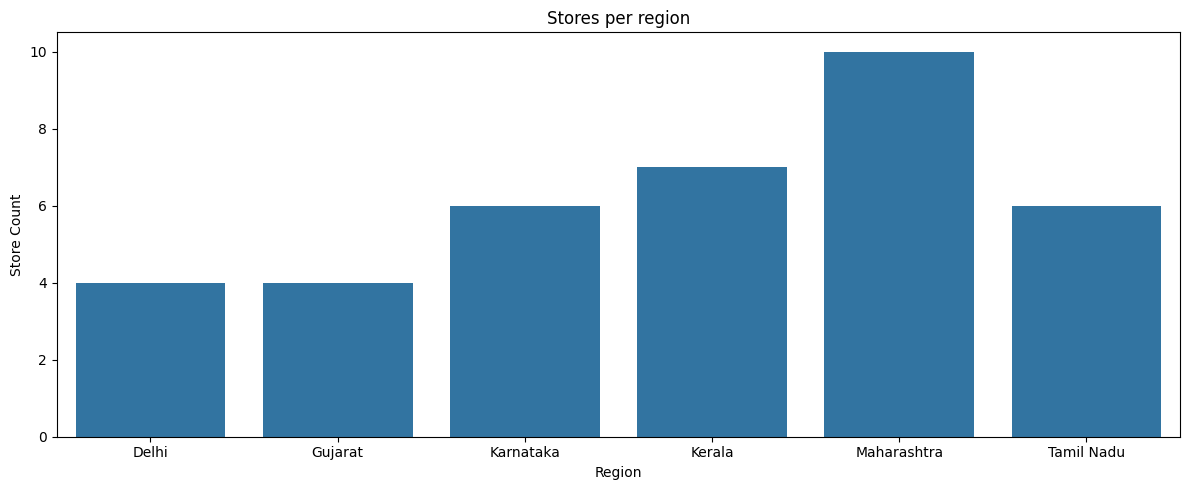

In [18]:
# Stores per region
stores_per_region = stores_df.groupby('region')['store_id'].nunique().reset_index()

# Plot
from helper_functions import plot_bar_chart
fig = plot_bar_chart(
    stores_per_region,
    "region",
    "store_id",
    "Stores per region",
    "Region",
    "Store Count"
)

In [19]:
from helper_functions import metro_city_dictionary
# Stores in metro v/s non metro cities
stores_per_city_type = stores_df.groupby("city")["store_id"].nunique().reset_index()
stores_per_city_type["is_metro"] = stores_per_city_type["city"].map(metro_city_dictionary)
stores_per_city_type

,city,store_id,is_metro
0,Ahmedabad,2,0
1,Bangalore,4,1
2,Chennai,2,1
3,Coimbatore,4,0
4,Kochi,4,0
5,Mumbai,4,1
6,Mysore,2,0
7,Nagpur,4,0
8,New Delhi,4,1
9,Pune,2,0


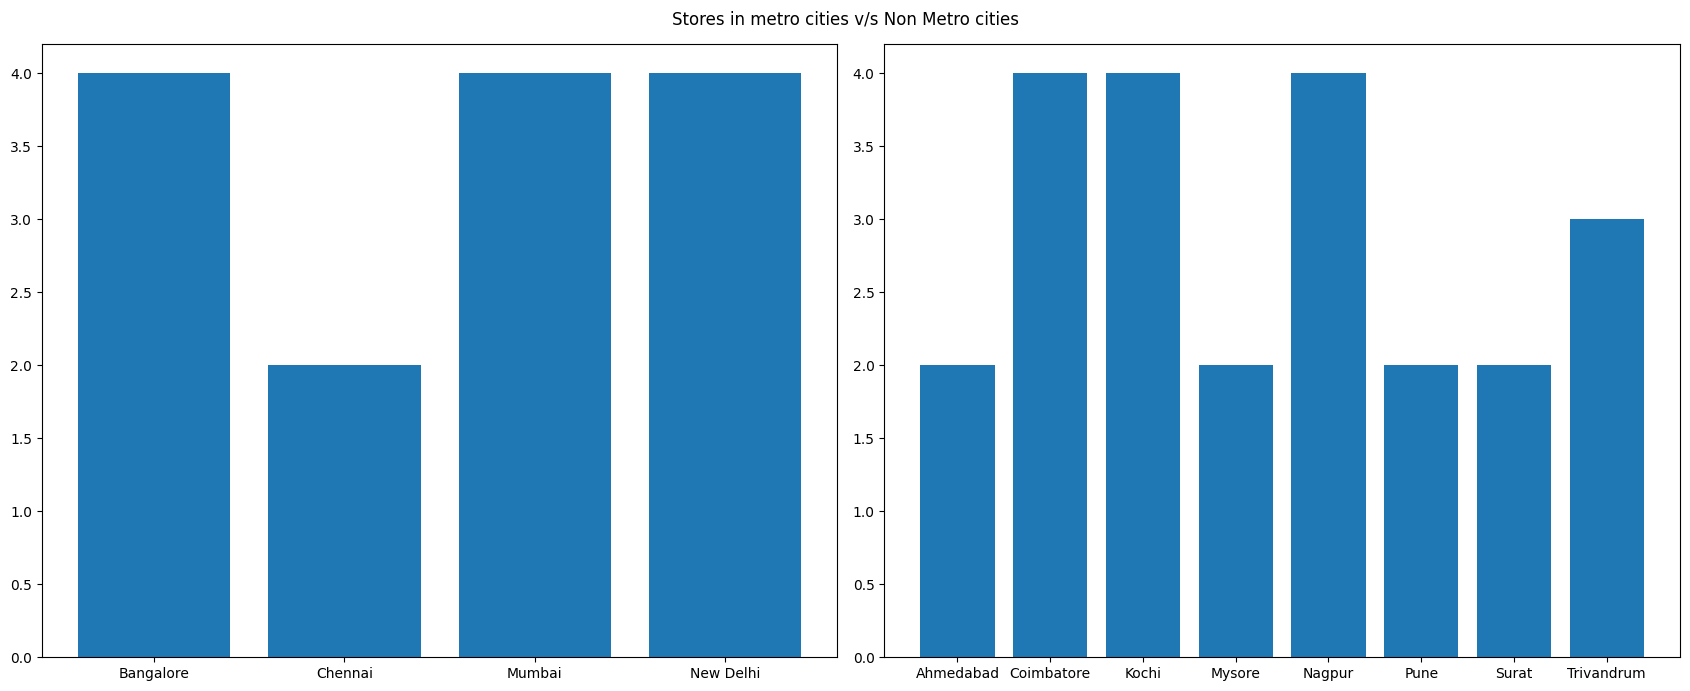

In [20]:
fig, ax = plt.subplots(figsize = (17, 7), ncols = 2)

fig.suptitle("Stores in metro cities v/s Non Metro cities")

ax[0].bar(stores_per_city_type[stores_per_city_type['is_metro'] == 1]['city'], stores_per_city_type[stores_per_city_type['is_metro'] ==1]['store_id'])

ax[1].bar(stores_per_city_type[stores_per_city_type['is_metro'] == 0]['city'], stores_per_city_type[stores_per_city_type['is_metro'] ==0]['store_id'])

plt.tight_layout()
fig.show()

In [21]:
# Store Size Analysis

# Avg Store size
avg_store_size = stores_df['store_size_sqft'].mean()
print(f"Average store size: {round(avg_store_size, 2)} sqft")

Average store size: 4160.46 sqft


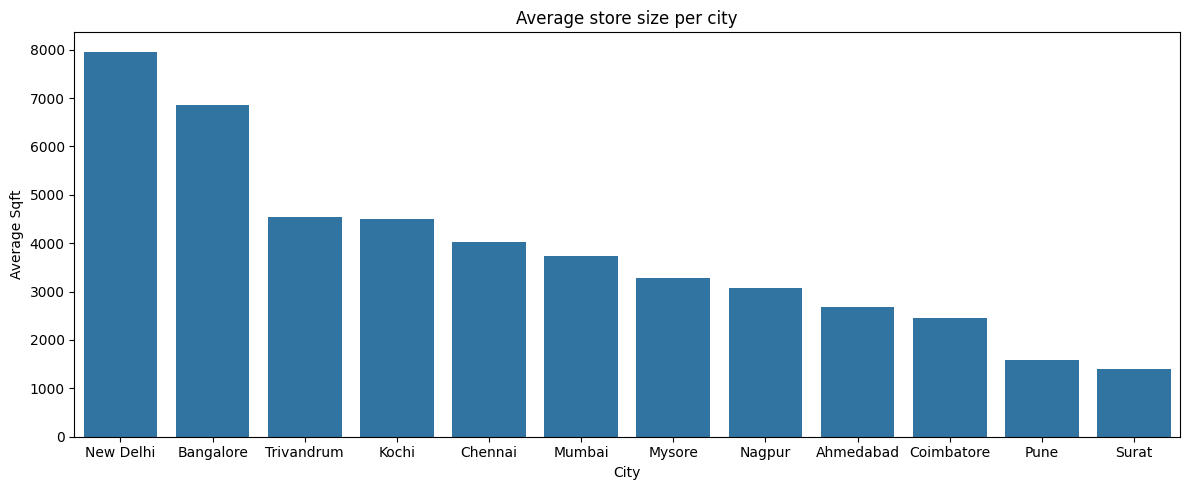

In [22]:
# Average store size per cities
store_size_per_city = stores_df.groupby('city')['store_size_sqft'].mean().reset_index().sort_values(by = 'store_size_sqft', ascending= False)

fig = plot_bar_chart(
    df = store_size_per_city, 
    x_col = "city", 
    y_col = "store_size_sqft", 
    title = "Average store size per city", 
    x_label = "City", 
    y_label = "Average Sqft"
)

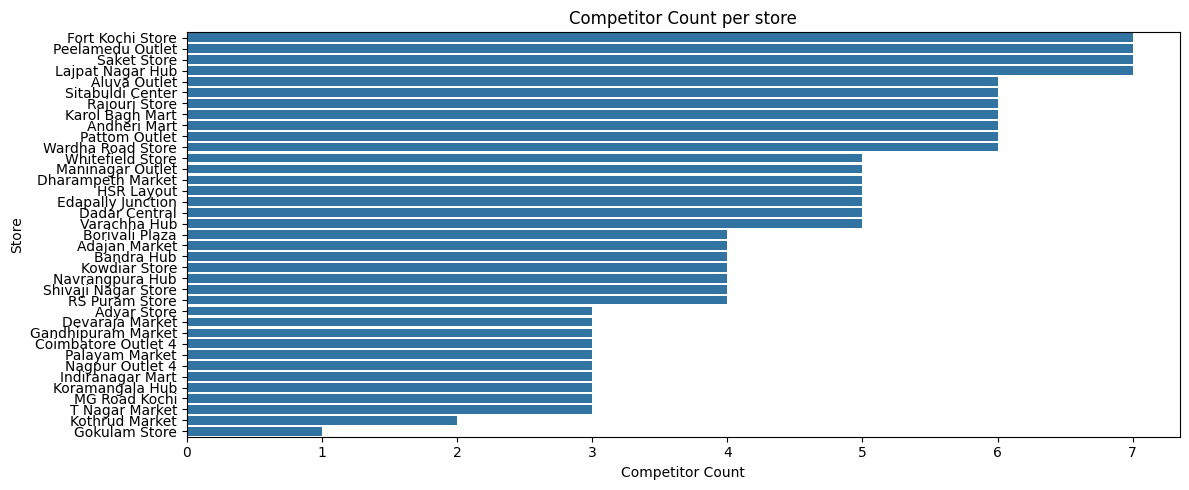

In [23]:
# Competition Analysis
competitor_count = stores_df.groupby('store')['local_competitor_count'].sum().reset_index().sort_values(by = 'local_competitor_count', ascending = False)

fig = plot_bar_chart(
    df = competitor_count,
    x_col = "store",
    y_col = "local_competitor_count",
    title = "Competitor Count per store",
    x_label = "Store",
    y_label = "Competitor Count",
    x_tick_rotation = 45,
    horizontal = True
)

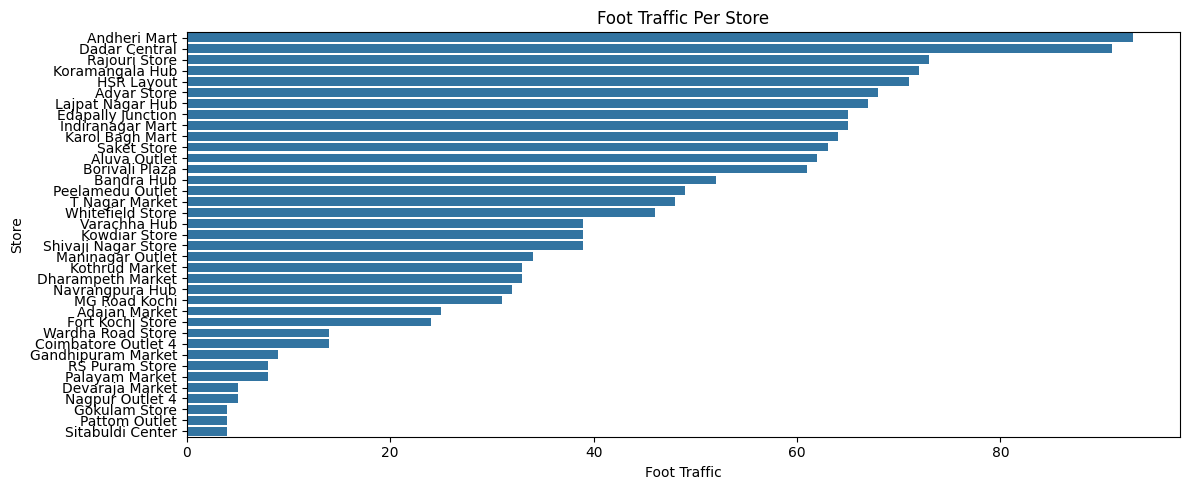

In [24]:
# Footfall Analysis
foot_traffic_index = stores_df.groupby('store')['foot_traffic_index'].sum().reset_index().sort_values(by = 'foot_traffic_index', ascending= False)

fig = plot_bar_chart(
    df = foot_traffic_index,
    x_col = 'store',
    y_col = 'foot_traffic_index',
    x_label = "Store",
    y_label = "Foot Traffic",
    title = "Foot Traffic Per Store",
    horizontal = True
)

<b> Findings </b> <br>
&nbsp;&nbsp; 1. Maharashtra has the most Stores per region <br>
&nbsp;&nbsp; 2. Average store size is 4160.46 sqft <br>
&nbsp;&nbsp; 3. New Delhi has the highest average store size when compared to other cities while Surat has the least store size out of all cities <br>
&nbsp;&nbsp; 4. Gokulam Store has the least competitior count (1) while Fort Kochi Store has the highest competitior count (7) <br>
&nbsp;&nbsp; 5. Andheri Mart has the highest foot traffic index while Sitabuldi center has the least <br>


## 4. Sales Data Analysis

1. Are higher sqft stores making more revenue? <br>
2. Store Size vs Revenue <br>
3. Store Size vs Demand <br>
4. Store Size vs Inventory <br>
5. Does higher competition reduce sales ? <br>
6. Does foot traffic correlate with Demand ? <br>
7. Do mall stores outperform street stores? <br>
8. Do mall stores carry more inventory ? <br>
9. Does parking increase sales ? <br>
10. Is parking more important for Electronics? <br>
11. Do old stores perform better? <br>
12. Do mature stores have larger customer bases? <br>
13. Do pickup-enabled storesd perform better? <br>
14. Does online pickup reduce stockouts? <br>
15. Which area type generates highest sales? <br>
16. Do premium stores sell more Electronics? <br>
17. Do premium stores have larger basket sizes> <br>
18. What categories perform best in student areas? <br>
19. Is demand more price-sensitive? <br>
20. Do office districts generate weekday demand? <br>
21. Is weekend demand weaker? <br>
22. Which stores have highest spending customers? <br>
23. Which regions have highest purchasing power? <br>
24. Which stores are hardest to replenish? <br>
25. Which regions have longest lead times? <br>
26. Which stores need larger safety stock? <br>
27. Which stores are vulnerable to stockouts? <br>
28. Store Scoring Model <br>
&nbsp;&nbsp; Store Score = 30% Revenue + 20% Demand + 20% Foot Traffic + 15% Basket Size + 15% Inventory Efficiency
29. Store Clustering <br>
 Using:
* store_size_sqft <br>
* foot_traffic_index <br>
* avg_basket_size <br>
* competitor_count <br>
* lead_time

### 1. Are higher sqft stores making more revenue?

In [25]:
revenue_by_sqft = sales_df.groupby('store_id').agg({
    'store_size_sqft': 'first',
    "sales": 'sum'
}).reset_index()
revenue_by_sqft.columns = ["store_id", 'sqft', 'total_revenue']
corr = revenue_by_sqft[['sqft', 'total_revenue']].corr().iloc[0, 1]
print(f"Correlation (sqft vs revenue) : {corr:.3f}")

Correlation (sqft vs revenue) : 0.602


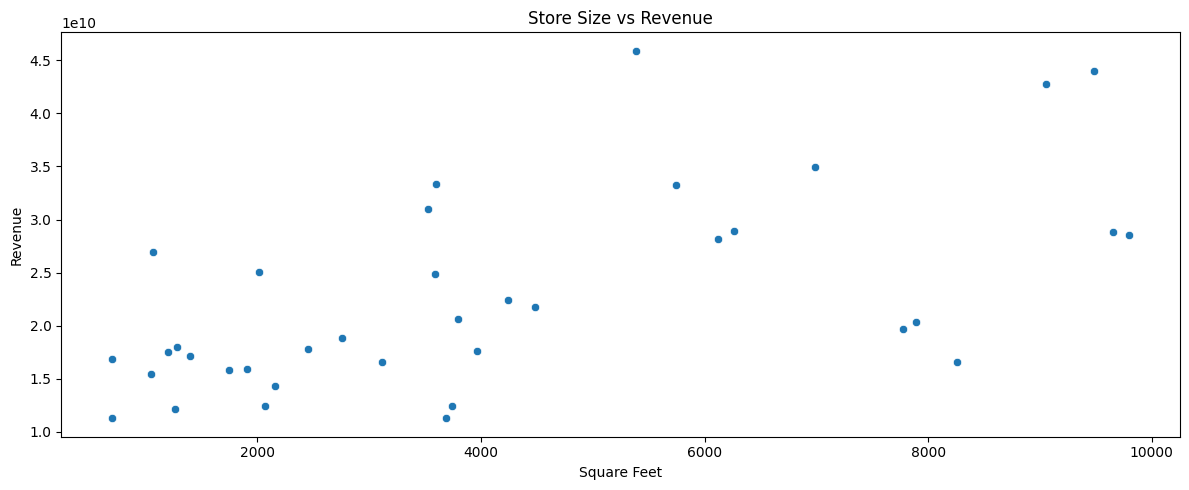

In [26]:
from helper_functions import plot_scatter_plot
fig = plot_scatter_plot(
    df = revenue_by_sqft,
    x_col = 'sqft',
    y_col = 'total_revenue',
    title = "Store Size vs Revenue",
    x_label = "Square Feet",
    y_label = "Revenue"
)

### 2. Store size v/s Revenue (pivot by category)

In [27]:
size_revenue_cat = sales_df.groupby(["store_id", "category"]).agg({
    "store_size_sqft": 'first',
    "sales": 'sum'
}).reset_index()

In [28]:
size_revenue_cat

,store_id,category,store_size_sqft,sales
0,1,Clothing,3592,3.872553e+09
1,1,Electronics,3592,1.984360e+10
2,1,Grocery,3592,1.149566e+09
3,2,Clothing,2015,3.943614e+09
4,2,Electronics,2015,1.993021e+10
...,...,...,...,...
106,36,Electronics,1743,1.243496e+10
107,36,Grocery,1743,4.907250e+08
108,37,Clothing,1050,2.782193e+09
109,37,Electronics,1050,1.217596e+10


In [29]:
pivot = size_revenue_cat.pivot_table(
    index = 'category',
    columns = 'store_size_sqft',
    values = 'sales',
    aggfunc = 'sum'
)
print("Revenue by Store Size & Category:\n", pivot)

Revenue by Store Size & Category:
 store_size_sqft          700           701           1050          1062  \
category                                                                  
Clothing         1.775349e+09  2.579977e+09  2.782193e+09  2.186591e+09   
Electronics      8.981276e+09  1.357383e+10  1.217596e+10  2.403083e+10   
Grocery          5.020878e+08  7.404337e+08  4.739932e+08  7.235986e+08   

store_size_sqft          1199          1263          1284          1396  \
category                                                                  
Clothing         1.373752e+09  1.853812e+09  1.402544e+09  3.044587e+09   
Electronics      1.574836e+10  9.781487e+09  1.608077e+10  1.364065e+10   
Grocery          4.371654e+08  5.251220e+08  4.560790e+08  4.830450e+08   

store_size_sqft          1743          1908          2015          2070  \
category                                                                  
Clothing         2.930652e+09  1.878862e+09  3.943614e+09  1.92

### 3. Store size v/s Demand

In [30]:
size_demand = sales_df.groupby("store_id").agg({
    "store_size_sqft": "first",
    "demand": "sum"
}).reset_index(); size_demand

,store_id,store_size_sqft,demand
0,1,3592,6608756
1,2,2015,6709129
2,3,5747,9132101
3,4,3600,8989473
4,5,2455,4525470
5,6,701,4299279
6,7,1263,3061815
7,8,8258,4193224
8,9,700,2917303
9,10,2070,3274707


In [31]:
corr_demand = size_demand[['store_size_sqft', 'demand']].corr().iloc[0,1]
print(f"Correlation (sqft v/s demand): {corr_demand:.3f}")

Correlation (sqft v/s demand): 0.523


### 4. Store Size vs Inventory

In [32]:
size_inventory = sales_df.groupby('store_id').agg({
    'store_size_sqft': 'first',
    'inventory': 'sum'
}).reset_index(); size_inventory

,store_id,store_size_sqft,inventory
0,1,3592,7569601
1,2,2015,7681674
2,3,5747,10456108
3,4,3600,10301633
4,5,2455,5164718
5,6,701,4896669
6,7,1263,3485353
7,8,8258,4778175
8,9,700,3317369
9,10,2070,3726825


In [33]:
corr_inv = size_inventory[['store_size_sqft', 'inventory']].corr().iloc[0, 1]
print(f"Correlation (sqft v/s Inventory): {corr_inv:.3f}")

Correlation (sqft v/s Inventory): 0.522


### 5. Does higher competition reduce sales ?

In [34]:
comp_sales = sales_df.groupby('store_id').agg({
    'local_competitor_count': 'first',
    "sales_qty": 'sum'
}).reset_index(); comp_sales

,store_id,local_competitor_count,sales_qty
0,1,4,6408931
1,2,4,6509142
2,3,5,8858133
3,4,6,8721885
4,5,2,4384467
5,6,4,4163452
6,7,6,2964162
7,8,5,4059142
8,9,6,2823112
9,10,3,3170747


In [35]:
corr_comp = comp_sales[['local_competitor_count', 'sales_qty']].corr().iloc[0, 1]
print(f"Correlation (competitors v/s Sales Qty): {corr_comp:.3f}")

Correlation (competitors v/s Sales Qty): 0.192


### 6. Does foot traffic correlate with demand?

In [36]:
traffic_demand = sales_df.groupby('store_id').agg({
    'foot_traffic_index': 'first',
    "demand": "sum"
}).reset_index()

In [37]:
corr_traffic = traffic_demand[['foot_traffic_index', "demand"]].corr().iloc[0, 1]
print(f"Correlation (Foot Traffic v/s Demand): {corr_traffic:.3f}")

Correlation (Foot Traffic v/s Demand): 0.915


### 7. Do mall stores outperform street stores?

In [38]:
mall_revenue = sales_df.groupby(['store_id', 'in_mall']).agg({
    'sales': 'sum'
}).reset_index(); mall_revenue

,store_id,in_mall,sales
0,1,0,2.486572e+10
1,2,0,2.505277e+10
2,3,1,3.323882e+10
3,4,1,3.333690e+10
4,5,0,1.780225e+10
5,6,0,1.689424e+10
6,7,0,1.216042e+10
7,8,1,1.660913e+10
8,9,0,1.125871e+10
9,10,0,1.237741e+10


In [39]:
mall_perf = mall_revenue.groupby('in_mall')['sales'].agg(['mean', 'sum', 'count'])
mall_perf.index = ['Street', 'Mall']; mall_perf

,mean,sum,count
Street,1.772672e+10,3.899879e+11,22
Mall,2.996379e+10,4.494569e+11,15


In [40]:
print("Mall v/s Street Performance:\n ", mall_perf)

Mall v/s Street Performance:
                  mean           sum  count
Street  1.772672e+10  3.899879e+11     22
Mall    2.996379e+10  4.494569e+11     15


### 8. Do mall stores carry more inventory?

In [41]:
mall_inventory = sales_df.groupby(['store_id', 'in_mall']).agg({'inventory': 'sum'}).reset_index(); mall_inventory

,store_id,in_mall,inventory
0,1,0,7569601
1,2,0,7681674
2,3,1,10456108
3,4,1,10301633
4,5,0,5164718
5,6,0,4896669
6,7,0,3485353
7,8,1,4778175
8,9,0,3317369
9,10,0,3726825


In [42]:
mall_inv = mall_inventory.groupby('in_mall')['inventory'].agg(['mean', 'sum', 'count'])
mall_inv.index = ['Street', 'Mall']
print('Mall v/s Street Inventory: \n', mall_inv)

Mall v/s Street Inventory: 
                 mean        sum  count
Street  4.205426e+06   92519365     22
Mall    6.857844e+06  102867656     15


### 9. Do old Stores outperform better?

In [43]:
store_age_revenue = sales_df.groupby('store_id').agg({
    'store_age_years': 'first',
    'sales': 'sum'
}).reset_index(); store_age_revenue

,store_id,store_age_years,sales
0,1,11,2.486572e+10
1,2,12,2.505277e+10
2,3,9,3.323882e+10
3,4,9,3.333690e+10
4,5,14,1.780225e+10
5,6,8,1.689424e+10
6,7,13,1.216042e+10
7,8,3,1.660913e+10
8,9,7,1.125871e+10
9,10,14,1.237741e+10


In [44]:
corr_age = store_age_revenue[['store_age_years', 'sales']].corr().iloc[0, 1]

In [45]:
print(f"Correlation (store age v/s revenue): {corr_age:.3f}")

Correlation (store age v/s revenue): -0.129


### 10. Do mature stores have larger customer base (higher demand) ?

In [46]:
store_age_demand = sales_df.groupby('store_id').agg({
    'store_age_years': 'first',
    'demand': 'sum'
}).reset_index()

In [47]:
corr_age_demand = store_age_demand[['store_age_years', 'demand']].corr().iloc[0, 1]
print(f"Correlation (store age vs demand): {corr_age_demand:.3f}")

Correlation (store age vs demand): 0.109


### 11. Which stores are harder to replenish?

In [48]:
replenish_hardness = sales_df.groupby('store_id').agg({
    'supplier_lead_time_days': 'first',
    'store': 'first',
    'city': 'first'
}).reset_index(drop = True); replenish_hardness

,supplier_lead_time_days,store,city
0,2,Bandra Hub,Mumbai
1,1,Borivali Plaza,Mumbai
2,1,Dadar Central,Mumbai
3,3,Andheri Mart,Mumbai
4,2,Kothrud Market,Pune
5,1,Shivaji Nagar Store,Pune
6,3,Wardha Road Store,Nagpur
7,4,Dharampeth Market,Nagpur
8,6,Sitabuldi Center,Nagpur
9,9,Nagpur Outlet 4,Nagpur


In [49]:
replenish_hardness = replenish_hardness.sort_values(by = 'supplier_lead_time_days', ascending = False)
print("Top 10 Hardest Stores to Replenish: \n", replenish_hardness.head(10))

Top 10 Hardest Stores to Replenish: 
     supplier_lead_time_days                store        city
9                         9      Nagpur Outlet 4      Nagpur
27                        9       RS Puram Store  Coimbatore
21                        8      Devaraja Market      Mysore
15                        7        Pattom Outlet  Trivandrum
28                        7  Coimbatore Outlet 4  Coimbatore
8                         6     Sitabuldi Center      Nagpur
14                        6        Kowdiar Store  Trivandrum
22                        5        Gokulam Store      Mysore
16                        5       Palayam Market  Trivandrum
7                         4    Dharampeth Market      Nagpur


### 12. Which regions have longest lead times?

In [50]:
region_lead_time = sales_df.groupby('region')['supplier_lead_time_days'].agg(['mean', 'max', 'count']).sort_values(by = 'mean', ascending = False)
print("Lead times by Region: \n", region_lead_time)

Lead times by Region: 
                  mean  max   count
region                            
Tamil Nadu   4.833333    9  443574
Kerala       4.000000    7  517503
Maharashtra  3.200000    9  778200
Karnataka    3.166667    8  536958
Delhi        2.750000    3  326844
Gujarat      2.500000    4  280152


### 13. Which stores need largest safety stock?

In [51]:
safety_stock = sales_df.groupby('store_id').agg({
    'store': 'first',
    'reorder_point': 'first',
    'demand': 'sum'
}).reset_index(drop = True)
safety_stock['demand_to_reorder_ratio'] = safety_stock['demand'] / safety_stock['reorder_point']
safety_stock = safety_stock.sort_values(by = 'reorder_point', ascending = False)
print("Top 10 Stores Needing Large Safety Stock: \n", safety_stock.head(10))

Top 10 Stores Needing Large Safety Stock: 
                   store  reorder_point   demand  demand_to_reorder_ratio
27       RS Puram Store            126  2644911             20991.357143
9       Nagpur Outlet 4             99  3274707             33077.848485
28  Coimbatore Outlet 4             98  2788259             28451.622449
21      Devaraja Market             96  3021865             31477.760417
8      Sitabuldi Center             72  2917303             40518.097222
14        Kowdiar Store             66  4332913             65650.196970
22        Gokulam Store             65  3204754             49303.907692
13        MG Road Kochi             52  3752373             72161.019231
7     Dharampeth Market             52  4193224             80638.923077
33      Navrangpura Hub             52  3501581             67338.096154


### 14. Which stores are vulnerable to stockouts?

In [52]:
stockout_vulnerability = sales_df.groupby('store_id').agg({
    'store': 'first',
    'city': 'first',
    'stockout_flag': 'sum',
    'lost_sales': 'sum',
    'sales_qty' : 'count'
}).reset_index(drop = True)

In [53]:
stockout_vulnerability['stockout_rate'] = stockout_vulnerability['stockout_flag'] / stockout_vulnerability['sales_qty']

In [54]:
print("Top 10 Vulnerable Stores (Stockout Rate):\n", stockout_vulnerability.head(10))

Top 10 Vulnerable Stores (Stockout Rate):
                  store    city  stockout_flag  lost_sales  sales_qty  \
0           Bandra Hub  Mumbai          22185      199825      77820   
1       Borivali Plaza  Mumbai          22134      199987      77820   
2        Dadar Central  Mumbai          22325      273968      77820   
3         Andheri Mart  Mumbai          22136      267588      77820   
4       Kothrud Market    Pune          22272      141003      77820   
5  Shivaji Nagar Store    Pune          22365      135827      77820   
6    Wardha Road Store  Nagpur          22179       97653      77820   
7    Dharampeth Market  Nagpur          22461      134082      77820   
8     Sitabuldi Center  Nagpur          22184       94191      77820   
9      Nagpur Outlet 4  Nagpur          22053      103960      77820   

   stockout_rate  
0       0.285081  
1       0.284426  
2       0.286880  
3       0.284451  
4       0.286199  
5       0.287394  
6       0.285004  
7       0.28

### 15. Which area type generates highest sales?

In [55]:
area_sales = sales_df.groupby('area_type').agg({
    'sales': ['sum', 'mean'],
    'demand': 'mean',
    'sales_qty': 'count'
}).round(2)

In [56]:
print("Sales by Area Type:\n", area_sales)

Sales by Area Type:
                     sales            demand sales_qty
                      sum       mean   mean     count
area_type                                            
commercial   3.071221e+11  277927.46  56.71   1105044
mixed        6.638797e+10  406236.44  60.68    163422
office       4.916159e+10  203785.35  37.66    241242
residential  2.503808e+11  293829.67  63.87    852129
student      1.663924e+11  319129.81  67.25    521394


### 16. Do Premium stores sell more electronics?

In [57]:
premium_electronics = sales_df[sales_df['category'] == 'Electronics'].groupby('premium_store_flag').agg({
    'sales_qty': 'sum',
    'sales': 'sum'
}).reset_index()
premium_electronics.index = ['Non-Premium', 'Premium']
print("Premium Stores: Electronics Sales:\n", premium_electronics)

Premium Stores: Electronics Sales:
              premium_store_flag  sales_qty         sales
Non-Premium                   0   11677232  4.369390e+11
Premium                       1    7084537  2.649445e+11


### 17. What categories perform better in student areas?

In [58]:
student_cats = sales_df[sales_df['student_area_flag'] == 1].groupby('category').agg({
    'sales': 'sum',
    'demand': 'sum',
    'sales_qty': 'sum'
}).sort_values(by='sales', ascending = False)

In [59]:
print("Category performance in student areas:\n", student_cats)

Category performance in student areas:
                     sales    demand  sales_qty
category                                      
Electronics  1.404782e+11   3894836    3757221
Clothing     1.998061e+10   7372104    7135742
Grocery      5.933536e+09  23794460   23087374


### 18. Which areas have the highest spending customers?

In [60]:
high_spending_stores = sales_df.groupby('store_id').agg({
    'store': 'first',
    'city': 'first',
    'avg_basket_size': 'first'
}).reset_index(drop = True).sort_values(by = 'avg_basket_size', ascending = False)

In [61]:
print("Top 10 stores by average basket size:\n", high_spending_stores.head(10))

Top 10 stores by average basket size:
                store       city  avg_basket_size
19   Koramangala Hub  Bangalore             3059
32       Saket Store  New Delhi             2656
30  Lajpat Nagar Hub  New Delhi             2649
31     Rajouri Store  New Delhi             2323
29   Karol Bagh Mart  New Delhi             2273
12      Aluva Outlet      Kochi             2245
23       Adyar Store    Chennai             2076
33   Navrangpura Hub  Ahmedabad             1969
34  Maninagar Outlet  Ahmedabad             1918
21   Devaraja Market     Mysore             1748


### 19. Which regions have highest purchasing power?

In [62]:
region_power = sales_df.groupby('region').agg({
    'avg_basket_size': 'mean',
    'gdp_per_capita': 'mean',
    'sales': 'sum'
}).sort_values(by = 'avg_basket_size', ascending = False)

In [63]:
print("Purchasing power by region:\n", region_power)

Purchasing power by region:
              avg_basket_size  gdp_per_capita         sales
region                                                    
Delhi            2475.250000   350000.000000  1.144410e+11
Gujarat          1784.500000   180000.000000  6.606285e+10
Karnataka        1734.666667   203333.333333  2.031443e+11
Tamil Nadu       1443.833333   160000.000000  1.364355e+11
Kerala           1248.000000   155714.285714  1.157648e+11
Maharashtra       904.800000   168000.000000  2.035964e+11


## 5. Feature Engineering Analysis

### 1. Does parking increase sales?

In [64]:
parking_sales = sales_df.groupby(['store_id', 'category']).agg({
    'parking_available': 'first',
    'sales': 'sum',
    'sales_qty': 'sum'
}).reset_index()

In [65]:
parking_comparison = parking_sales.groupby(['parking_available', 'category']).agg({
    'sales': ['mean', 'sum'],
    'sales_qty': 'mean'
})

In [66]:
print("Impact of Parking on Sales by Category:\n", parking_comparison)

Impact of Parking on Sales by Category:
                                       sales                   sales_qty
                                       mean           sum          mean
parking_available category                                             
0                 Clothing     2.526024e+09  1.263012e+10  9.010740e+05
                  Electronics  1.516031e+10  7.580154e+10  4.054828e+05
                  Grocery      5.840538e+08  2.920269e+09  2.281841e+06
1                 Clothing     3.037612e+09  9.720357e+10  1.082986e+06
                  Electronics  1.956506e+10  6.260819e+11  5.229486e+05
                  Grocery      7.752311e+08  2.480740e+10  3.015894e+06


### 2. Is parking more important for Electronics?

In [67]:
electronics_parking = sales_df[sales_df['category'] == 'Electronics'].groupby('parking_available').agg({
    'sales_qty': 'mean',
    'sales': 'mean'
}).reset_index()

In [68]:
electronics_parking.index = ['No parking', 'Parking']

In [69]:
print("Parking impact on Electronic Sales:\n", electronics_parking[['sales_qty', 'sales']])

Parking impact on Electronic Sales:
             sales_qty          sales
No parking  13.711899  512664.442986
Parking     20.776740  777319.492687


### 3. Do pickup-enabled stores perform better?

In [70]:
pickup_revenue = sales_df.groupby(['store_id', 'category']).agg({
    'online_pickup_point': 'first',
    'sales': 'sum'
}).reset_index()

In [71]:
pickup_perf = pickup_revenue.groupby(['online_pickup_point', 'category'])['sales'].agg(['mean', 'sum'])
pickup_perf.index.names = ['Pickup', 'Category']
print("Pickup enabled stores Performance:\n", pickup_perf)

Pickup enabled stores Performance:
                             mean           sum
Pickup Category                               
0      Clothing     2.795888e+09  5.032599e+10
       Electronics  1.792028e+10  3.225650e+11
       Grocery      7.383408e+08  1.329013e+10
1      Clothing     3.131984e+09  5.950770e+10
       Electronics  1.996413e+10  3.793185e+11
       Grocery      7.598701e+08  1.443753e+10


### 4. Does Online Pickups reduce stockouts?

In [72]:
pickup_stockout = sales_df.groupby('online_pickup_point').agg({
    'stockout_flag': 'sum',
    'sales_qty': 'count'
}).reset_index()

In [73]:
pickup_stockout['stockout_rate'] = pickup_stockout['stockout_flag']/ pickup_stockout['sales_qty']
pickup_stockout.index = ['No Pickup', 'Pickup']

In [74]:
print("Stockout Rate by Pickup Availability:\n", pickup_stockout[['stockout_flag', 'sales_qty', 'stockout_rate']])

Stockout Rate by Pickup Availability:
            stockout_flag  sales_qty  stockout_rate
No Pickup         397213    1389087       0.285953
Pickup            425317    1494144       0.284656


### 5. Is demand more price-sensitive? (Discount v/s Sales Qty)

In [75]:
discount_sensitivity = sales_df.groupby('discount').agg({
    'sales_qty': ['mean', 'sum'],
    'sales': 'mean'
}).round(2)

In [76]:
discount_sensitivity.index.name = 'Discount %'

In [77]:
print("Price sensitivity (Discount v/s Sales Qty): \n", discount_sensitivity)

Price sensitivity (Discount v/s Sales Qty): 
            sales_qty                sales
                mean       sum       mean
Discount %                               
0              57.46  66299005  311710.30
5              57.62  33236739  295215.47
10             57.51  33178625  280427.88
15             57.56  16560178  265455.59
20             57.53  16565959  247749.91


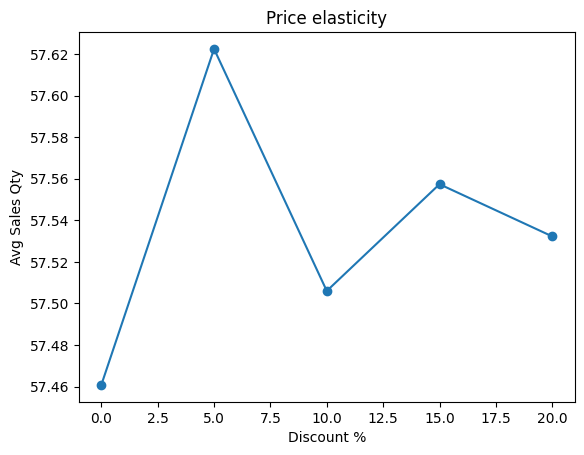

In [78]:
discount_demand = sales_df.groupby('discount')['sales_qty'].mean()
plt.plot(discount_demand.index, discount_demand.values, marker = 'o')
plt.xlabel('Discount %'); plt.ylabel('Avg Sales Qty')
plt.title("Price elasticity")
plt.show()

### 6. Do office districts generate weekday demand?

In [79]:
office_weekday = sales_df[sales_df['office_area_flag'] == 1].groupby('is_weekend').agg({
    'demand': 'mean',
    'sales_qty': 'mean'
}).reset_index()
office_weekday['day_type'] = ['Weekday', 'Weekend']
print("Demand patterns in Office Areas:\n", office_weekday[['day_type', 'demand', 'sales_qty']])

Demand patterns in Office Areas:
   day_type     demand  sales_qty
0  Weekday  35.582787  34.413330
1  Weekend  42.846194  41.494996


### 7. Is weekend demand weaker? (Overall trend)

In [80]:
weekend_demand = sales_df.groupby('is_weekend').agg({
    'demand': 'mean',
    'sales_qty': 'mean',
    'sales': 'mean'
}).reset_index()
weekend_demand['day_type'] = ['Weekday', 'Weekend']

In [81]:
print("Weekend v/s Weekday demand:\n", weekend_demand[['day_type', 'demand', 'sales_qty', 'sales']])

Weekend v/s Weekday demand:
   day_type     demand  sales_qty          sales
0  Weekday  56.130555  54.382022  275046.417394
1  Weekend  67.439990  65.358553  331384.851405


## 6. Aggregation & Scoring

### 1. Store Scoring Model <br>
<p> Score = 30% Revenue + 20% Demand + 20% Foot Traffic + 15% Basket Size + 15% Inventory Efficiency

In [82]:
store_metrics = sales_df.groupby('store_id').agg({
    'store': 'first',
    'city': 'first',
    'sales': 'sum',
    'demand': 'sum',
    'foot_traffic_index': 'first',
    'avg_basket_size': 'first',
    'inventory': 'sum',
    'sales_qty': 'sum'
}).reset_index(drop = True)

In [83]:
from helper_functions import normalize_score

store_metrics['rev_score'] = normalize_score(store_metrics['sales'])
store_metrics['demand_score'] = normalize_score(store_metrics['demand'])
store_metrics['traffic_score'] = normalize_score(store_metrics['foot_traffic_index'])
store_metrics['basket_score'] = normalize_score(store_metrics['avg_basket_size'])

In [84]:
store_metrics['inventory_efficiency'] = store_metrics['sales_qty'] / (store_metrics['inventory'] + 1)
store_metrics['efficiency_score'] = normalize_score(store_metrics['inventory_efficiency'])

In [85]:
store_metrics['store_score'] = (
    store_metrics['rev_score'] * 0.30 +
    store_metrics['demand_score'] * 0.20 +
    store_metrics['traffic_score'] * 0.20 +
    store_metrics['basket_score'] * 0.15 +
    store_metrics['efficiency_score'] * 0.15
)

In [86]:
store_metrics.sort_values(by ='store_score', ascending = False, inplace = True)
print("Top 10 Performing Stores:\n ", store_metrics[['store', 'city', 'store_score']].head(10))

Top 10 Performing Stores:
                 store       city  store_score
19   Koramangala Hub  Bangalore    73.070302
18        HSR Layout  Bangalore    62.801828
20  Indiranagar Mart  Bangalore    62.763784
2      Dadar Central     Mumbai    60.986978
3       Andheri Mart     Mumbai    59.871144
23       Adyar Store    Chennai    58.534253
30  Lajpat Nagar Hub  New Delhi    56.075182
32       Saket Store  New Delhi    55.813926
29   Karol Bagh Mart  New Delhi    55.433696
31     Rajouri Store  New Delhi    53.906916


## 7. Store Clustering

In [89]:
cluster_features = sales_df.groupby('store_id').agg({
    'store_size_sqft': 'first',
    'foot_traffic_index': 'first',
    'avg_basket_size': 'first',
    'local_competitor_count': 'first',
    'supplier_lead_time_days': 'first'
}).reset_index(drop = True)

In [92]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

In [93]:
kmeans = KMeans(n_clusters = 4, random_state = 42)
cluster_labels = kmeans.fit_predict(scaled_features)

In [94]:
cluster_features['cluster'] = cluster_labels

In [95]:
cluster_summary = cluster_features.groupby('cluster').agg({
    'store_size_sqft': 'mean',
    'foot_traffic_index': 'mean',
    'avg_basket_size': 'mean',
    'local_competitor_count': 'mean',
    'supplier_lead_time_days': 'mean'
}).round(2)

In [96]:
print('Store Clusters:\n', cluster_summary)

Store Clusters:
          store_size_sqft  foot_traffic_index  avg_basket_size  \
cluster                                                         
0                1705.09               33.18          1463.91   
1                7849.11               67.22          2282.11   
2                4649.38               56.62           997.38   
3                3038.22               10.11          1030.33   

         local_competitor_count  supplier_lead_time_days  
cluster                                                   
0                          3.91                     2.64  
1                          5.11                     2.11  
2                          5.50                     2.38  
3                          3.67                     6.89  


In [97]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(scaled_features, cluster_labels)
print(f"Silhouette Score: {sil_score:.3f}")

Silhouette Score: 0.250


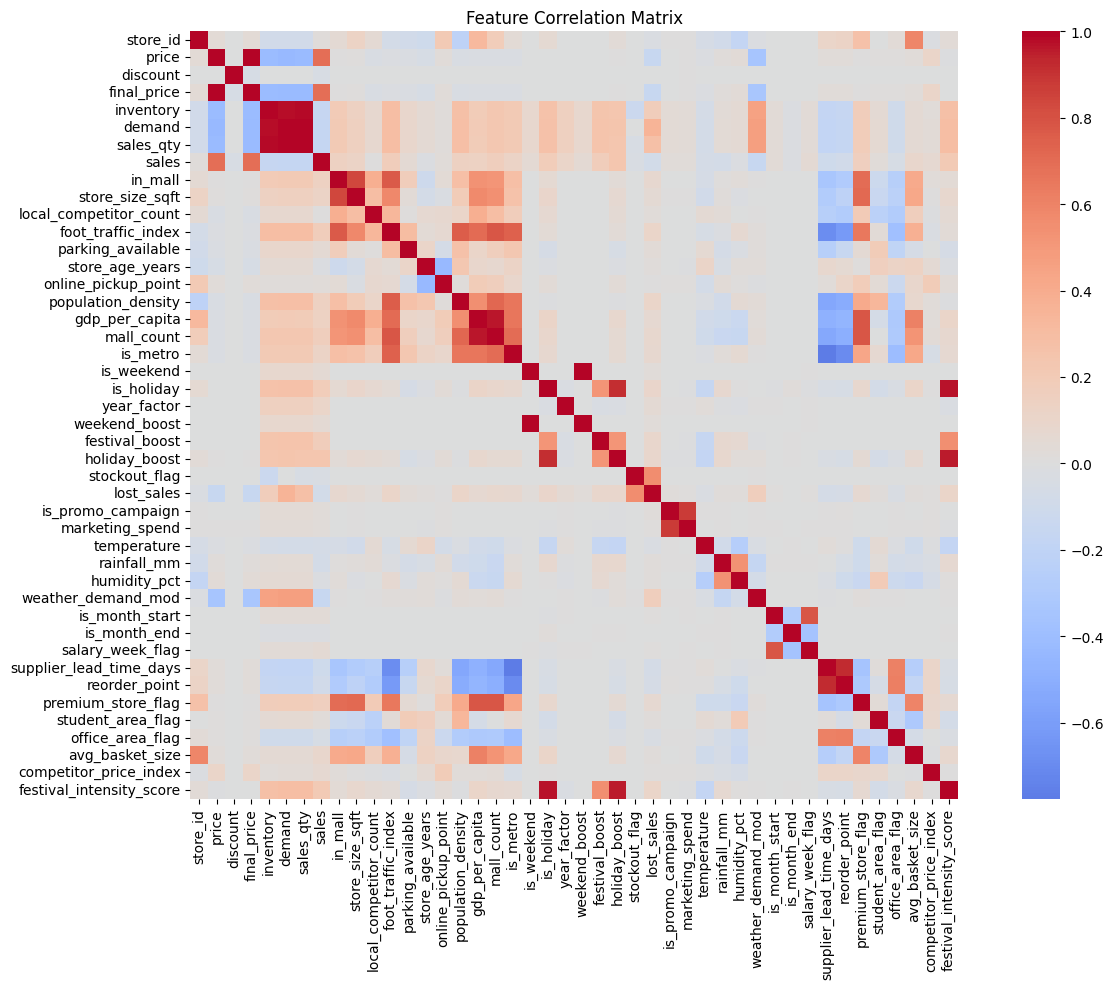

In [98]:
numeric_cols = sales_df.select_dtypes(include = [np.number]).columns
corr_matrix = sales_df[numeric_cols].corr()
plt.figure(figsize = (14, 10))
sns.heatmap(corr_matrix, cmap = 'coolwarm', center = 0, square = True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()